# GABRIEL Text + Image Analysis Tutorial

This notebook demonstrates how to use GABRIEL to analyze images (and combine text with images).

## Prerequisites

Set environment variables for Azure OpenAI:
```bash
export AZURE_OPENAI_API_KEY="your-api-key"
export AZURE_OPENAI_ENDPOINT="https://your-endpoint.openai.azure.com/"
```

## What You'll Learn

1. **Image-only analysis** - Rate, extract, and classify images
2. **Text + Image combined** - Analyze images with accompanying text context
3. **Batch processing** - Process multiple images at once
4. **Custom prompts** - Use `whatever()` for flexible multimodal analysis

## Step 1: Setup and Imports

In [ ]:
import os
import sys
import pandas as pd
from pathlib import Path

# Add src to path if running from notebooks directory
sys.path.insert(0, os.path.abspath('../src'))

import gabriel

# Configure your API credentials
os.environ["AZURE_OPENAI_API_KEY"] = "THE_API_KEY"
os.environ["AZURE_OPENAI_ENDPOINT"] = "THE_ENDPOINT"

# Create output directory
output_dir = "image_analysis_output"
os.makedirs(output_dir, exist_ok=True)

print("GABRIEL loaded successfully!")

/Users/pingzhili/anaconda3/envs/stats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GABRIEL loaded successfully!


## Step 2: Load Example Images

We have 5 product images in `examples/images/`:
- Watch
- Headphones
- Shoe
- Sunglasses
- Sneaker

In [2]:
# Define paths to example images
# IMPORTANT: Use absolute paths to avoid path resolution issues
import os

# Get the notebook's directory
notebook_dir = os.path.dirname(os.path.abspath("__file__"))
image_dir = Path(os.path.abspath("../examples/images"))

# List all images
image_files = sorted(image_dir.glob("*.jpg"))
print(f"Found {len(image_files)} images in: {image_dir}")
print(f"Image directory exists: {image_dir.exists()}")
print()
for img in image_files:
    abs_path = img.resolve()
    print(f"  - {img.name}")
    print(f"    Path: {abs_path}")
    print(f"    Exists: {abs_path.exists()}")

Found 5 images in: /Users/pingzhili/my-github/GABRIEL-prerelease/examples/images
Image directory exists: True

  - product_headphones.jpg
    Path: /Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_headphones.jpg
    Exists: True
  - product_shoe.jpg
    Path: /Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_shoe.jpg
    Exists: True
  - product_sneaker.jpg
    Path: /Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_sneaker.jpg
    Exists: True
  - product_sunglasses.jpg
    Path: /Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_sunglasses.jpg
    Exists: True
  - product_watch.jpg
    Path: /Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_watch.jpg
    Exists: True


In [3]:
# Display the images (if running in Jupyter with IPython display)
try:
    from IPython.display import Image, display, HTML
    
    html = '<div style="display: flex; flex-wrap: wrap; gap: 10px;">'
    for img_path in image_files:
        html += f'<div style="text-align: center;"><img src="{img_path}" width="150"/><br/><small>{img_path.name}</small></div>'
    html += '</div>'
    display(HTML(html))
except ImportError:
    print("IPython not available - images loaded but not displayed")

## Example A: Extract Information from Images

`gabriel.extract()` with `modality="image"` pulls structured facts from images.

In [4]:
# Create DataFrame with image paths
# IMPORTANT: Use absolute paths (str(p.resolve())) for reliable loading

df_images = pd.DataFrame({
    "image_id": [f"img_{i}" for i in range(len(image_files))],
    "image_path": [str(p.resolve()) for p in image_files],  # Absolute paths!
    "filename": [p.name for p in image_files]
})

# Verify all paths exist
print("Verifying image paths:")
for idx, row in df_images.iterrows():
    path = row["image_path"]
    exists = os.path.exists(path)
    print(f"  {row['filename']}: {'✓' if exists else '✗'} ({path})")
    
print()
df_images

Verifying image paths:
  product_headphones.jpg: ✓ (/Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_headphones.jpg)
  product_shoe.jpg: ✓ (/Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_shoe.jpg)
  product_sneaker.jpg: ✓ (/Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_sneaker.jpg)
  product_sunglasses.jpg: ✓ (/Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_sunglasses.jpg)
  product_watch.jpg: ✓ (/Users/pingzhili/my-github/GABRIEL-prerelease/examples/images/product_watch.jpg)



,image_id,image_path,filename
0,img_0,/Users/pingzhili/my-github/GABRIEL-prerelease/...,product_headphones.jpg
1,img_1,/Users/pingzhili/my-github/GABRIEL-prerelease/...,product_shoe.jpg
2,img_2,/Users/pingzhili/my-github/GABRIEL-prerelease/...,product_sneaker.jpg
3,img_3,/Users/pingzhili/my-github/GABRIEL-prerelease/...,product_sunglasses.jpg
4,img_4,/Users/pingzhili/my-github/GABRIEL-prerelease/...,product_watch.jpg


In [5]:
# Extract structured information from each image
extracted = await gabriel.extract(
    df=df_images,
    column_name="image_path",
    attributes={
        "product_type": "What type of product is shown? (e.g., watch, shoe, electronics)",
        "primary_color": "What is the dominant color of the product?",
        "background_color": "What is the background color? (e.g., white, gradient, colored)",
        "target_audience": "Who is the likely target audience? (e.g., young adults, professionals, athletes)",
        "brand_style": "What brand style does this suggest? (e.g., luxury, sporty, minimalist, casual)",
    },
    modality="image",  # <-- Key parameter for image analysis!
    save_dir=f"{output_dir}/extraction",
    model="gpt-5.2",
    reset_files=True,  # <-- Clear cached results from previous runs!
)

# Display results
display_cols = ["filename", "product_type", "primary_color", "background_color", "target_audience", "brand_style"]
extracted[display_cols]

[Extract] Rendering 5 prompts…


2026-01-15 16:15:26,076 - gabriel.utils.openai_utils - WARNING - ⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/


Initializing model calls and loading data...

===== Run kickoff =====
Prompts: 5 | Words: ~2,680 | Words per prompt: ~536
Model: gpt-5.2 | Mode: streaming
Pricing for model 'gpt-5.2': input $1.75/1M, output $14.0/1M
Estimated token usage: input 4,020, output 2,500 | ~1,804 tokens per call
Estimated synchronous cost: $0.04 (input: $0.01, output: $0.04)

===== Run limits =====
Requests per minute: unknown (API did not share a request limit)
Tokens per minute: unknown (API did not share a token limit)
Approx. words per minute: unknown
We can run up to 650 requests at the same time with your current settings.
⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/

Usage tiers (higher tier = faster runs):
  • Free: qualify by User must be in an allowed geography; monthly quota $100 / month
  • Tier 1: qualify by $5 added
  • Tier 

Processing prompts:   0%|          | 0/5 [00:00<?, ?it/s]

[parallelization] 2026-01-15 16:15:26 | Initial parallelization settings: cost_so_far=$0.00, cap=650, active=0, inflight=0, queue=5, processed=0/5, rate_limit_errors=0, throughput<=650 prompts/min


Processing prompts:  60%|██████    | 3/5 [00:04<00:02,  1.14s/it]

[dynamic timeout] Initialized timeout to 11.0s (p90=4.4s, factor=2.50).


Processing prompts: 100%|██████████| 5/5 [00:04<00:00,  1.04it/s]

[token estimate] Refreshed per-prompt estimates from observed usage (5 samples): input ≈ 1,274 tokens, output (incl. reasoning) ≈ 60 tokens.
[token estimate] Updated estimated total cost: ~$0.02 (input $0.01, output $0.00). Updated parallel threads: 650 based on refreshed token usage.
[token estimate] Updated time estimate: minimum of 1 minute. Moving to a higher usage tier raises rate limits and allows much faster runs.
Actual total cost: $0.02; average per row: $0.00; average per 1000 rows: $3.07

=== Extraction coverage ===
product_type                                           :     5 extracted,     0 unknown
primary_color                                          :     5 extracted,     0 unknown
background_color                                       :     5 extracted,     0 unknown
target_audience                                        :     5 extracted,     0 unknown
brand_style                                            :     5 extracted,     0 unknown



,filename,product_type,primary_color,background_color,target_audience,brand_style
0,product_headphones.jpg,headphones,black,yellow,young adults,modern
1,product_shoe.jpg,shoe,red,red,athletes,sporty
2,product_sneaker.jpg,shoes,white,white,young adults,casual
3,product_sunglasses.jpg,sunglasses,black,white,young adults,casual
4,product_watch.jpg,watch,white,light gray,professionals,minimalist


## Example B: Rate Images on Visual Attributes

`gabriel.rate()` with `modality="image"` scores images on 0-100 scales.

In [6]:
# Rate visual qualities of each product image
ratings = await gabriel.rate(
    df=df_images,
    column_name="image_path",
    attributes={
        "visual_appeal": "How visually appealing is this product image? (100 = stunning, 0 = unappealing)",
        "professionalism": "How professional does the product photography look? (100 = studio quality, 0 = amateur)",
        "luxury_perception": "How luxurious does the product appear? (100 = very luxurious, 0 = budget/cheap)",
        "minimalism": "How minimalist is the image composition? (100 = very minimal, 0 = cluttered)",
        "innovation_feel": "How innovative or modern does the product look? (100 = cutting-edge, 0 = outdated)",
    },
    modality="image",
    save_dir=f"{output_dir}/ratings",
    model="gpt-5.2",
    reset_files=True,  # <-- Clear cached results
)

# Display ratings
rating_cols = ["filename", "visual_appeal", "professionalism", "luxury_perception", "minimalism", "innovation_feel"]
ratings[rating_cols]

[Rate] Rendering 5 prompts…


2026-01-15 16:15:33,097 - gabriel.utils.openai_utils - WARNING - ⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/


Initializing model calls and loading data...

===== Run kickoff =====
Prompts: 5 | Words: ~1,805 | Words per prompt: ~361
Model: gpt-5.2 | Mode: streaming
Pricing for model 'gpt-5.2': input $1.75/1M, output $14.0/1M
Estimated token usage: input 2,705, output 2,500 | ~1,541 tokens per call
Estimated synchronous cost: $0.04 (input: $0.00, output: $0.04)

===== Run limits =====
Requests per minute: unknown (API did not share a request limit)
Tokens per minute: unknown (API did not share a token limit)
Approx. words per minute: unknown
We can run up to 650 requests at the same time with your current settings.
⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/

===== Example prompt =====
  Carefully consider and analyze the provided image content. Comprehend it fully, both big picture and relevant subtleties.



  Your task: f

Processing prompts:   0%|          | 0/5 [00:00<?, ?it/s]

[parallelization] 2026-01-15 16:15:33 | Initial parallelization settings: cost_so_far=$0.00, cap=650, active=0, inflight=0, queue=5, processed=0/5, rate_limit_errors=0, throughput<=650 prompts/min


Processing prompts: 100%|██████████| 5/5 [00:04<00:00,  1.23it/s]


[dynamic timeout] Initialized timeout to 9.9s (p90=4.0s, factor=2.50).
[token estimate] Refreshed per-prompt estimates from observed usage (5 samples): input ≈ 1,012 tokens, output (incl. reasoning) ≈ 51 tokens.
[token estimate] Updated estimated total cost: ~$0.01 (input $0.01, output $0.00). Updated parallel threads: 650 based on refreshed token usage.
[token estimate] Updated time estimate: minimum of 1 minute. Moving to a higher usage tier raises rate limits and allows much faster runs.
Actual total cost: $0.01; average per row: $0.00; average per 1000 rows: $2.49


,filename,visual_appeal,professionalism,luxury_perception,minimalism,innovation_feel
0,product_headphones.jpg,84.0,88.0,61.0,93.0,74.0
1,product_shoe.jpg,89.0,92.0,62.0,84.0,78.0
2,product_sneaker.jpg,84.0,89.0,58.0,78.0,73.0
3,product_sunglasses.jpg,71.0,74.0,62.0,86.0,48.0
4,product_watch.jpg,78.0,86.0,62.0,93.0,71.0


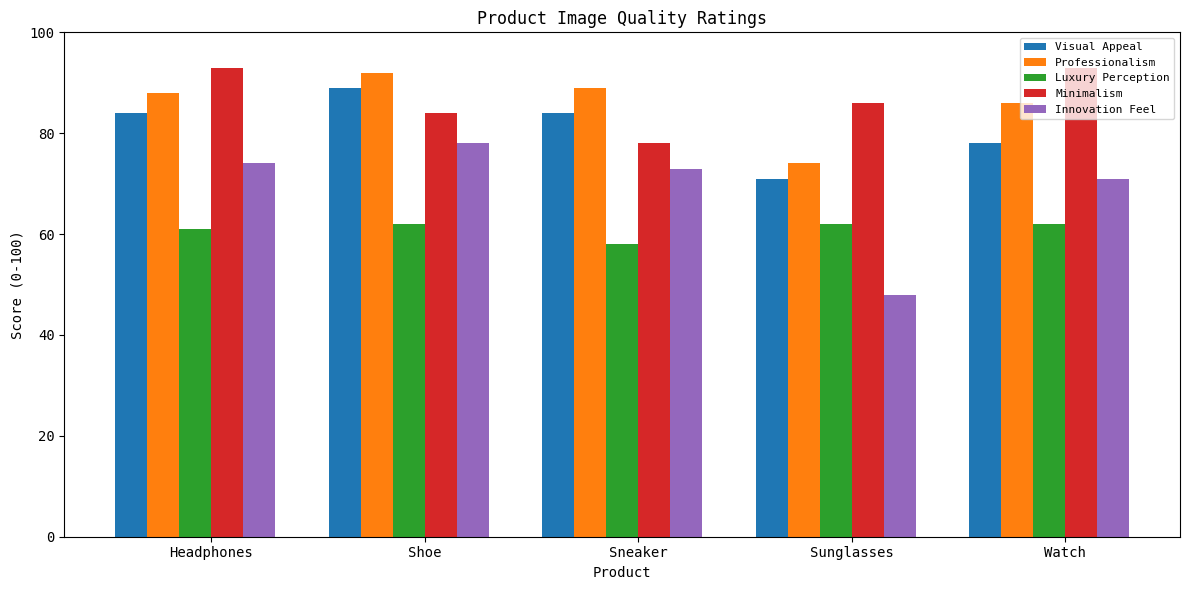

In [7]:
# Visualize ratings as a bar chart
try:
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    metrics = ["visual_appeal", "professionalism", "luxury_perception", "minimalism", "innovation_feel"]
    x = range(len(ratings))
    width = 0.15
    
    for i, metric in enumerate(metrics):
        offset = (i - len(metrics)/2) * width
        ax.bar([xi + offset for xi in x], ratings[metric], width, label=metric.replace("_", " ").title())
    
    ax.set_xlabel("Product")
    ax.set_ylabel("Score (0-100)")
    ax.set_title("Product Image Quality Ratings")
    ax.set_xticks(x)
    ax.set_xticklabels([f.replace("product_", "").replace(".jpg", "").title() for f in ratings["filename"]])
    ax.legend(loc="upper right", fontsize=8)
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available - skipping visualization")

## Example C: Classify Images

`gabriel.classify()` with `modality="image"` assigns images to predefined categories.

In [8]:
# Classify products into categories
# Note: gabriel.classify uses 'labels' parameter (not 'attributes')
classified = await gabriel.classify(
    df=df_images,
    column_name="image_path",
    labels={
        "is_footwear": "The product is a type of footwear (shoes, sneakers, boots, etc.)",
        "is_electronics": "The product is electronics (headphones, phone, etc.)",
        "is_accessory": "The product is a fashion accessory (watch, sunglasses, etc.)",
    },
    modality="image",
    save_dir=f"{output_dir}/classification",
    model="gpt-5.2",
    reset_files=True,
)

# Display classifications
class_cols = ["filename", "is_footwear", "is_electronics", "is_accessory"]
classified[class_cols]

[Classify] Rendering 5 prompts…


2026-01-15 16:15:40,465 - gabriel.utils.openai_utils - WARNING - ⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/


Initializing model calls and loading data...

===== Run kickoff =====
Prompts: 5 | Words: ~915 | Words per prompt: ~183
Model: gpt-5.2 | Mode: streaming
Pricing for model 'gpt-5.2': input $1.75/1M, output $14.0/1M
Estimated token usage: input 1,370, output 2,500 | ~1,274 tokens per call
Estimated synchronous cost: $0.04 (input: $0.00, output: $0.04)

===== Run limits =====
Requests per minute: unknown (API did not share a request limit)
Tokens per minute: unknown (API did not share a token limit)
Approx. words per minute: unknown
We can run up to 650 requests at the same time with your current settings.
⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/

===== Example prompt =====
  Carefully consider and analyze the provided image content. Comprehend it fully, both big picture and relevant subtleties.




  Task: For eac

Processing prompts:   0%|          | 0/5 [00:00<?, ?it/s]

[parallelization] 2026-01-15 16:15:40 | Initial parallelization settings: cost_so_far=$0.00, cap=650, active=0, inflight=0, queue=5, processed=0/5, rate_limit_errors=0, throughput<=650 prompts/min


Processing prompts: 100%|██████████| 5/5 [00:02<00:00,  1.78it/s]

[dynamic timeout] Initialized timeout to 6.6s (p90=2.7s, factor=2.50).
[token estimate] Refreshed per-prompt estimates from observed usage (5 samples): input ≈ 726 tokens, output (incl. reasoning) ≈ 32 tokens.
[token estimate] Updated estimated total cost: ~$0.01 (input $0.01, output $0.00). Updated parallel threads: 650 based on refreshed token usage.
[token estimate] Updated time estimate: minimum of 1 minute. Moving to a higher usage tier raises rate limits and allows much faster runs.
Actual total cost: $0.01; average per row: $0.00; average per 1000 rows: $1.72
[Classify] Filled 5/5 unique texts.

=== Label coverage (non-null) ===
is_footwear                                            : 100.00% (5/5)
is_electronics                                         : 100.00% (5/5)
is_accessory                                           : 100.00% (5/5)



,filename,is_footwear,is_electronics,is_accessory
0,product_headphones.jpg,False,True,False
1,product_shoe.jpg,True,False,False
2,product_sneaker.jpg,True,False,False
3,product_sunglasses.jpg,False,False,True
4,product_watch.jpg,False,True,True


## Example D: Text + Image Combined Analysis

A powerful use case is combining product images with descriptive text (e.g., product descriptions, reviews) for richer analysis.

In [9]:
# Create a dataset with both images and product descriptions
product_descriptions = [
    "Sleek minimalist watch with premium leather band. Perfect for professionals who value understated elegance.",
    "Wireless over-ear headphones with active noise cancellation. 30-hour battery life, premium sound quality.",
    "Limited edition running shoe with responsive cushioning. Designed for marathon runners and serious athletes.",
    "Classic aviator sunglasses with polarized lenses. UV400 protection, lightweight titanium frame.",
    "Retro-inspired sneakers with modern comfort technology. Street style meets everyday wearability."
]

df_combined = pd.DataFrame({
    "product_id": [f"prod_{i}" for i in range(len(image_files))],
    "image_path": [str(p.resolve()) for p in image_files],
    "description": product_descriptions,
    "filename": [p.name for p in image_files]
})

df_combined[["filename", "description"]]

,filename,description
0,product_headphones.jpg,Sleek minimalist watch with premium leather ba...
1,product_shoe.jpg,Wireless over-ear headphones with active noise...
2,product_sneaker.jpg,Limited edition running shoe with responsive c...
3,product_sunglasses.jpg,Classic aviator sunglasses with polarized lens...
4,product_watch.jpg,Retro-inspired sneakers with modern comfort te...


## Example E: Compare Two Images

`gabriel.compare()` with `modality="image"` compares pairs of images on specified criteria.

In [11]:
# Create pairs of images to compare
# Let's compare footwear products (shoe vs sneaker)

image_paths = [str(p.resolve()) for p in image_files]
shoe_path = [p for p in image_paths if "shoe" in p][0]
sneaker_path = [p for p in image_paths if "sneaker" in p][0]

df_compare = pd.DataFrame({
    "comparison_id": ["footwear_comparison"],
    "circle_image": [shoe_path],   # "circle" = first image (A)
    "square_image": [sneaker_path]  # "square" = second image (B)
})

print(f"Comparing:")
print(f"  Circle (A): {Path(shoe_path).name}")
print(f"  Square (B): {Path(sneaker_path).name}")

Comparing:
  Circle (A): product_shoe.jpg
  Square (B): product_sneaker.jpg


In [12]:
# Compare the two footwear products
# Note: gabriel.compare uses circle_column_name and square_column_name
# It returns a table of differences (not numeric comparisons)
comparison = await gabriel.compare(
    df=df_compare,
    circle_column_name="circle_image",
    square_column_name="square_image",
    modality="image",
    save_dir=f"{output_dir}/comparison",
    model="gpt-5.2",
    reset_files=True,
)

# Display comparison results
# The output shows differences between Circle (A) and Square (B)
print("\nComparison Results (Differences found):")
print("-" * 60)
if "attribute" in comparison.columns and "explanation" in comparison.columns:
    for idx, row in comparison.iterrows():
        print(f"\n• {row['attribute']}")
        print(f"  {row['explanation']}")
else:
    print(comparison.to_string())

[Compare] Rendering 1 prompts…


2026-01-15 16:15:59,328 - gabriel.utils.openai_utils - WARNING - ⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/


Initializing model calls and loading data...

===== Run kickoff =====
Prompts: 1 | Words: ~535 | Words per prompt: ~535
Model: gpt-5.2 | Mode: streaming
Pricing for model 'gpt-5.2': input $1.75/1M, output $14.0/1M
Estimated token usage: input 802, output 500 | ~1,802 tokens per call
Estimated synchronous cost: $0.01 (input: $0.00, output: $0.01)

===== Run limits =====
Requests per minute: unknown (API did not share a request limit)
Tokens per minute: unknown (API did not share a token limit)
Approx. words per minute: unknown
We can run up to 650 requests at the same time with your current settings.
⚠️ API did not return complete rate-limit headers. Running with conservative defaults. If you are on a free/low-balance plan, add funds to avoid quota blocks: https://platform.openai.com/settings/organization/billing/

===== Example prompt =====
  Two images are provided. **SQUARE = first image. CIRCLE = second image.** Comprehend both fully (overall + fine detail).
  Again, "circle" refere

Processing prompts:   0%|          | 0/1 [00:00<?, ?it/s]

[parallelization] 2026-01-15 16:15:59 | Initial parallelization settings: cost_so_far=$0.00, cap=650, active=0, inflight=0, queue=1, processed=0/1, rate_limit_errors=0, throughput<=650 prompts/min


Processing prompts: 100%|██████████| 1/1 [00:19<00:00, 19.27s/it]

[dynamic timeout] Initialized timeout to 48.2s (p90=19.3s, factor=2.50).
[token estimate] Refreshed per-prompt estimates from observed usage (1 sample): input ≈ 1,668 tokens, output (incl. reasoning) ≈ 362 tokens.
[token estimate] Updated estimated total cost: ~$0.01 (input $0.00, output $0.01). Updated parallel threads: 577 based on refreshed token usage.
[token estimate] Updated time estimate: minimum of 1 minute. Moving to a higher usage tier raises rate limits and allows much faster runs.
Actual total cost: $0.01; average per row: $0.01; average per 1000 rows: $7.99

Comparison Results (Differences found):
------------------------------------------------------------

• circle shows a single shoe while square shows a pair
  Circle contains one sneaker only, angled in space; square clearly shows two shoes (one on a white block and another leaning against it).

• circle has a monochrome red color scheme while square is multicolored
  Circle is dominated by red (upper, laces, backgroun

## Example F: Using `gabriel.load()` to Load Image Folders

For larger projects, use `gabriel.load()` to automatically load all images from a folder into a DataFrame.

In [14]:
# Load all images from a directory
df_loaded = gabriel.load(
    "../examples/images",
    modality="image"
)

print(f"Loaded {len(df_loaded)} images")
df_loaded

                     name                                       path
0     product_sneaker.jpg     ../examples/images/product_sneaker.jpg
1  product_sunglasses.jpg  ../examples/images/product_sunglasses.jpg
2  product_headphones.jpg  ../examples/images/product_headphones.jpg
3       product_watch.jpg       ../examples/images/product_watch.jpg
4        product_shoe.jpg        ../examples/images/product_shoe.jpg
Saved aggregated file to ../examples/images/gabriel_aggregated_content.csv
Loaded 5 images


,name,path
0,product_sneaker.jpg,../examples/images/product_sneaker.jpg
1,product_sunglasses.jpg,../examples/images/product_sunglasses.jpg
2,product_headphones.jpg,../examples/images/product_headphones.jpg
3,product_watch.jpg,../examples/images/product_watch.jpg
4,product_shoe.jpg,../examples/images/product_shoe.jpg


## Tips and Best Practices

### Testing Mode
Use `use_dummy=True` to test your pipeline without consuming API credits:
```python
result = await gabriel.rate(..., modality="image", use_dummy=True)
```

### Image Input Formats
GABRIEL accepts images as:
- **Local file paths**: `/path/to/image.jpg`
- **URLs**: `https://example.com/image.png`
- **Base64 encoded strings**: For programmatic image generation

### Supported Image Formats
- JPEG (`.jpg`, `.jpeg`)
- PNG (`.png`)
- GIF (`.gif`)
- WebP (`.webp`)

### Checkpointing
GABRIEL automatically saves intermediate results. If interrupted, re-running resumes from checkpoint:
```python
result = await gabriel.rate(..., reset_files=True)  # Start fresh
```

### Cost Optimization
Image analysis uses more tokens than text. Tips to reduce costs:
- Use smaller images when possible (resize before analysis)
- Batch similar analyses together
- Use `use_dummy=True` for testing pipelines

## GABRIEL Function Reference for Images

| Function | Image Use Case | Key Parameters | Output |
|----------|----------------|----------------|--------|
| `extract()` | Pull facts from images | `attributes={}` | Strings/numbers |
| `rate()` | Score visual attributes | `attributes={}` | 0-100 scores |
| `classify()` | Categorize images | `labels={}` | True/False per label |
| `compare()` | Compare image pairs | `circle_column_name`, `square_column_name` | Difference descriptions |
| `whatever()` | Custom image analysis | `prompts=` | Any format |
| `rank()` | Rank images by criteria | `criterion=` | Rankings |
| `load()` | Load images from folder | `path=`, `modality="image"` | DataFrame |

### Key Parameter

**`modality="image"`** - This is the key parameter that tells GABRIEL to process the column as images rather than text.

```python
# Text analysis (default)
result = await gabriel.rate(df, "text_column", attributes=...)

# Image analysis
result = await gabriel.rate(df, "image_path_column", attributes=..., modality="image")
```

### Important Notes

1. **Use absolute paths** for image files to avoid path resolution issues
2. **Use `reset_files=True`** to clear cached results when re-running
3. **`classify()` uses `labels=`**, not `attributes=`
4. **`compare()` uses `circle_column_name` and `square_column_name`** (circle=first, square=second)

## Summary

In this tutorial, you learned how to:

1. **Extract** structured information from images (product type, colors, etc.)
2. **Rate** images on visual attributes (appeal, professionalism, luxury)
3. **Classify** images into categories (product category, price tier)
4. **Combine** images with text for richer analysis
5. **Compare** pairs of images on multiple criteria
6. **Load** images from folders using `gabriel.load()`

The key is the `modality="image"` parameter - add it to any GABRIEL function to switch from text to image analysis!